In [1]:
import pandas as pd
from arch import arch_model

ftse = pd.read_csv("ftse100_close_2015_2026.csv", parse_dates=["date"], index_col="date")["close"]
returns = ftse.pct_change().dropna() * 100
returns.shape

(2955,)

In [2]:
modelo_garch11 = arch_model(returns, mean="Constant", vol="GARCH", p=1, q=1)
resultado_garch11 = modelo_garch11.fit(disp="off")
print(resultado_garch11.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3587.46
Distribution:                  Normal   AIC:                           7182.92
Method:            Maximum Likelihood   BIC:                           7206.88
                                        No. Observations:                 2955
Date:                Wed, Sep 16 2026   Df Residuals:                     2954
Time:                        18:52:40   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0405  1.334e-02      3.037  2.391e-03 [1.

In [3]:
print("Comparacion de AIC (mismos datos, FTSE 100 2015-2026):")
print("  ARCH(6)      -- 7 parametros de volatilidad :", 7198.43)
print("  GARCH(1,1)   -- 3 parametros de volatilidad  :", round(resultado_garch11.aic, 2))

Comparacion de AIC (mismos datos, FTSE 100 2015-2026):
  ARCH(6)      -- 7 parametros de volatilidad : 7198.43
  GARCH(1,1)   -- 3 parametros de volatilidad  : 7182.92


In [4]:
resultados = []
for p in range(1, 3):
    for q in range(1, 3):
        m = arch_model(returns, mean="Constant", vol="GARCH", p=p, q=q)
        r = m.fit(disp="off")
        resultados.append({"p": p, "q": q, "log_likelihood": r.loglikelihood, "aic": r.aic, "bic": r.bic})

tabla = pd.DataFrame(resultados)
tabla

,p,q,log_likelihood,aic,bic
0,1,1,-3587.458368,7182.916735,7206.881751
1,1,2,-3580.470349,7170.940698,7200.896968
2,2,1,-3587.458368,7184.916735,7214.873005
3,2,2,-3580.470349,7172.940698,7208.888222


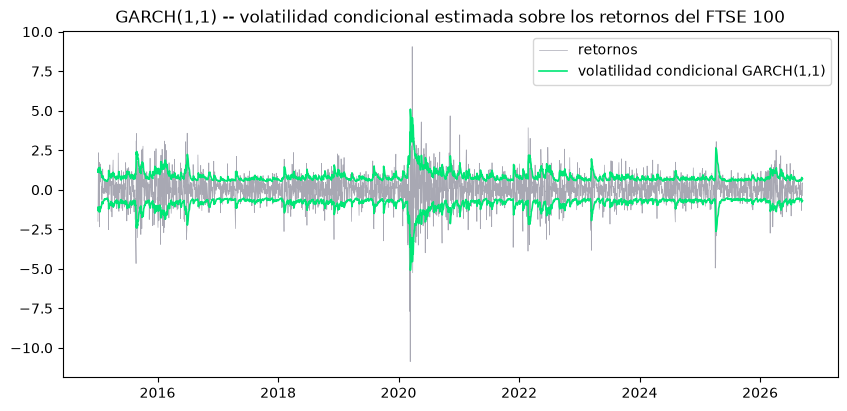

In [5]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

vol_condicional = resultado_garch11.conditional_volatility

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns.index, returns, color="#a8a8b3", linewidth=0.5, label="retornos")
ax.plot(vol_condicional.index, vol_condicional, color="#00e676", linewidth=1.2, label="volatilidad condicional GARCH(1,1)")
ax.plot(vol_condicional.index, -vol_condicional, color="#00e676", linewidth=1.2)
ax.legend()
ax.set_title("GARCH(1,1) -- volatilidad condicional estimada sobre los retornos del FTSE 100")
plt.savefig("ftse-garch-volatilidad-condicional.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
pronostico = resultado_garch11.forecast(horizon=10)
vol_futura = pronostico.variance.iloc[-1] ** 0.5
print("Volatilidad diaria pronosticada para los proximos 10 dias (%):")
print(vol_futura)
print()
print("alpha[1] + beta[1] =", round(resultado_garch11.params["alpha[1]"] + resultado_garch11.params["beta[1]"], 4),
      "(persistencia de la volatilidad; cerca de 1 = shocks de volatilidad que tardan en disiparse)")

Volatilidad diaria pronosticada para los proximos 10 dias (%):
h.01    0.675028
h.02    0.693752
h.03    0.710745
h.04    0.726213
h.05    0.740328
h.06    0.753235
h.07    0.765059
h.08    0.775908
h.09    0.785877
h.10    0.795049
Name: 2026-09-15 00:00:00, dtype: float64

alpha[1] + beta[1] = 0.9313 (persistencia de la volatilidad; cerca de 1 = shocks de volatilidad que tardan en disiparse)
